In [3]:
import os
import pandas as pd
import re

In [6]:
!pip install ace_tools

In [4]:
# Diretório base
base_dir = r"C:\Users\Carol\Documents\Data Code and Deliverables\Data Group Part\Data\clinical-trial-outcome-prediction\Processed\hint"

In [11]:
# Lista para armazenar estatísticas
results = []

# Itera sobre arquivos CSV no diretório
for filename in os.listdir(base_dir):
    if filename.endswith(".csv"):
        filepath = os.path.join(base_dir, filename)
        df = pd.read_csv(filepath)

        # Extrai fase e tipo de divisão do nome do arquivo (ex: phase_I_train.csv)
        match = re.match(r"(phase_[IVX]+)_(train|test|valid)\.csv", filename)
        if match:
            phase, split = match.groups()

            num_trials = len(df)
            num_drugs = df['smiles'].nunique() if 'smiles' in df.columns else 0
            num_diseases = df['diseases'].nunique() if 'diseases' in df.columns else 0
            num_success = df['label'].sum() if 'label' in df.columns else 0
            num_failures = num_trials - num_success

            results.append({
                'phase': phase,
                'split': split,
                'num_trials': num_trials,
                'num_drugs': num_drugs,
                'num_diseases': num_diseases,
                'successes': num_success,
                'failures': num_failures
            })

# Converte para DataFrame
summary_df = pd.DataFrame(results)

In [12]:
print(summary_df)

       phase  split  num_trials  num_drugs  num_diseases  successes  failures
0  phase_III   test         893        341           679        641       252
1  phase_III  train        4165        897          2251       3601       564
2  phase_III  valid         894        365           709        726       168
3   phase_II   test        1449        442          1123        863       586
4   phase_II  train        6761       1273          3549       5393      1368
5   phase_II  valid        1452        470          1134       1073       379
6    phase_I   test        1160        329           714        897       263
7    phase_I  train        5417       1256          2665       4640       777
8    phase_I  valid        1159        385           754        910       249


In [18]:
# Diretório base
base_dir = r"C:\Users\Carol\Documents\Data Code and Deliverables\Data Group Part\Data\clinical-trial-outcome-prediction\Processed\ctod"

In [21]:
# Lista para armazenar estatísticas
results_ctod = []

# Itera sobre arquivos CSV no diretório
for filename in os.listdir(base_dir):
    if filename.endswith(".csv"):
        filepath = os.path.join(base_dir, filename)
        df = pd.read_csv(filepath)

        # Extrai fase e tipo de divisão do nome do arquivo (ex: phase_I_train.csv)
        match = re.match(r"(phase_[IVX]+)_(train|valid)\.csv", filename)
        if match:
            phase, split = match.groups()

            num_trials = len(df)
            num_drugs = df['smiles'].nunique() if 'smiles' in df.columns else 0
            num_diseases = df['diseases'].nunique() if 'diseases' in df.columns else 0
            num_success = df['label'].sum() if 'label' in df.columns else 0
            num_failures = num_trials - num_success

            results_ctod.append({
                'phase': phase,
                'split': split,
                'num_trials': num_trials,
                'num_drugs': num_drugs,
                'num_diseases': num_diseases,
                'successes': num_success,
                'failures': num_failures
            })

# Converte para DataFrame
summary_df_ctod = pd.DataFrame(results_ctod)

In [22]:
print(summary_df_ctod)

       phase  split  num_trials  num_drugs  num_diseases  successes  failures
0  phase_III  train        3572       1563          1415       3004       568
1  phase_III  valid         893        565           503        741       152
2   phase_II  train        5390       2055          2101       4112      1278
3   phase_II  valid        1348        754           712       1028       320
4    phase_I  train        4016       1752          1271       3326       690
5    phase_I  valid        1006        623           447        820       186


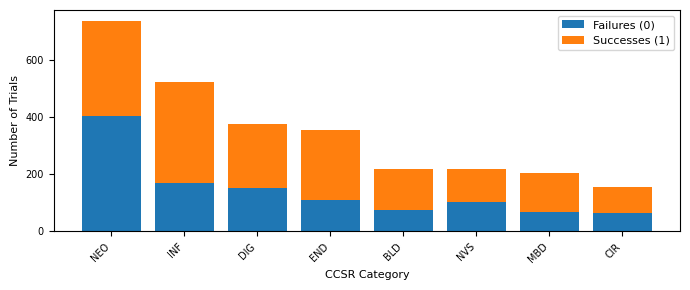

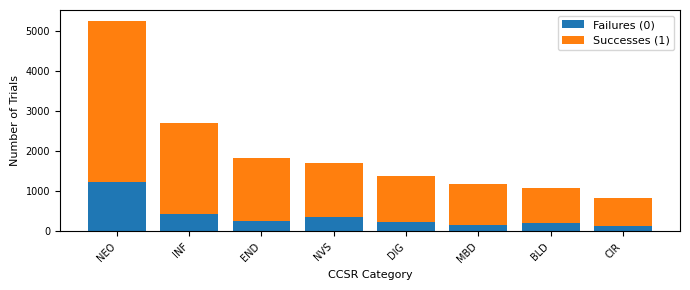

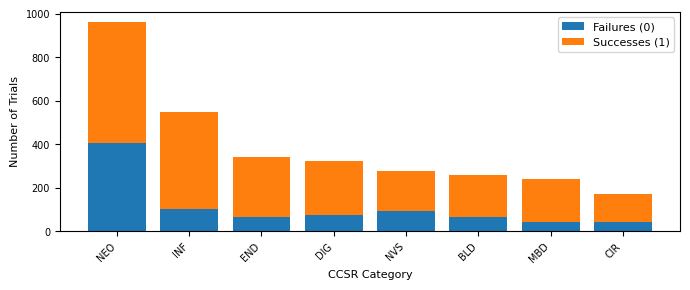

In [47]:
import os
import pandas as pd
import ast
import matplotlib.pyplot as plt
import re

# --- Diretório base --- #
base_dir = r"C:\Users\Carol\Documents\Data Code and Deliverables\Data Group Part\Data\clinical-trial-outcome-prediction\Processed\hint"

# --- Carregar mapeamento ICD → CCSR --- #
def load_icd2ccsr(file="icdcode/icd2ccsr.txt"):
    with open(file, "r") as f:
        return dict(line.strip().split("\t") for line in f)

icd2ccsr = load_icd2ccsr()

# --- Carregar e anotar os dados por split --- #
all_dfs = []
for filename in os.listdir(base_dir):
    if filename.endswith(".csv"):
        match = re.match(r"phase_[IVX]+_(train|valid|test)\.csv", filename)
        if not match:
            continue  # pular arquivos que não seguem o padrão
        split = match.group(1)

        filepath = os.path.join(base_dir, filename)
        df = pd.read_csv(filepath)
        df["split"] = split
        all_dfs.append(df)

df_all = pd.concat(all_dfs, ignore_index=True)

# --- Converter string de ICDs para listas reais --- #
def parse_icd_column(text):
    try:
        return ast.literal_eval(text)
    except:
        return []

df_all["icd_list"] = df_all["icdcodes"].apply(parse_icd_column)

# --- Expandir uma linha por ICD code e filtrar Unknown --- #
expanded_rows = []
for _, row in df_all.iterrows():
    for icd in row["icd_list"]:
        icd = str(icd).strip()
        if icd:
            ccsr = icd2ccsr.get(icd)
            if ccsr:  # automaticamente exclui None e "Unknown"
                expanded_rows.append({
                    "ccsr": ccsr,
                    "label": row["label"],
                    "split": row["split"]
                })

df_expanded = pd.DataFrame(expanded_rows)

# --- Agrupar por CCSR e Split e contar os rótulos --- #
summary = df_expanded.groupby(["split", "ccsr", "label"]).size().unstack(fill_value=0).reset_index()
summary.columns = ["split", "ccsr", "failures (0)", "successes (1)"]

# --- Gráficos empilhados com cores padrão --- #
for split in summary["split"].unique():
    df_plot = summary[summary["split"] == split].copy()
    df_plot["total"] = df_plot["failures (0)"] + df_plot["successes (1)"]
    df_plot = df_plot.sort_values("total", ascending=False).head(8)

    plt.figure(figsize=(7, 3))
    plt.bar(df_plot["ccsr"], df_plot["failures (0)"], label="Failures (0)")  # padrão: laranja
    plt.bar(df_plot["ccsr"], df_plot["successes (1)"], bottom=df_plot["failures (0)"], label="Successes (1)")  # padrão: azul

    #plt.title(f"Top 8 CCSR Categories – {split.capitalize()}", fontsize=10)
    plt.xlabel("CCSR Category", fontsize=8)
    plt.ylabel("Number of Trials", fontsize=8)
    plt.xticks(rotation=45, ha="right", fontsize=7)
    plt.yticks(fontsize=7)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [36]:
# --- Coletar todos os nct_id de HINT ---
hint_nct_ids = set()
hint_dir = r"C:\Users\Carol\Documents\Data Code and Deliverables\Data Group Part\Data\clinical-trial-outcome-prediction\Processed\hint"

for filename in os.listdir(hint_dir):
    if filename.endswith(".csv"):
        df = pd.read_csv(os.path.join(hint_dir, filename))
        if 'NCT Number' in df.columns:
            hint_nct_ids.update(df['NCT Number'].dropna().astype(str))

# --- Coletar todos os nct_id de CTOD ---
ctod_nct_ids = set()
ctod_dir = r"C:\Users\Carol\Documents\Data Code and Deliverables\Data Group Part\Data\clinical-trial-outcome-prediction\Processed\ctod"

for filename in os.listdir(ctod_dir):
    if filename.endswith(".csv"):
        df = pd.read_csv(os.path.join(ctod_dir, filename))
        if 'nct_id' in df.columns:
            ctod_nct_ids.update(df['nct_id'].dropna().astype(str))

# --- Verificar interseção ---
matching_ids = hint_nct_ids.intersection(ctod_nct_ids)

# --- Resultado ---
print(f"Total HINT nct_ids: {len(hint_nct_ids)}")
print(f"Total CTOD nct_ids: {len(ctod_nct_ids)}")
print(f"Matching nct_ids: {len(matching_ids)}")

if matching_ids:
    print("Example matching nct_ids:", list(matching_ids)[:5])
else:
    print("No nct_id matches found.")


Total HINT nct_ids: 22818
Total CTOD nct_ids: 15837
Matching nct_ids: 4305
Example matching nct_ids: ['NCT01024660', 'NCT05220293', 'NCT03015246', 'NCT01761747', 'NCT03887754']


In [40]:
import pandas as pd
import os

# Diretórios
hint_dir = r"C:\Users\Carol\Documents\Data Code and Deliverables\Data Group Part\Data\clinical-trial-outcome-prediction\Processed\hint"
ctod_dir = r"C:\Users\Carol\Documents\Data Code and Deliverables\Data Group Part\Data\clinical-trial-outcome-prediction\Processed\ctod"

# Coletar todos os nct_id de HINT
hint_nct_ids = set()
hint_rows = []
for filename in os.listdir(hint_dir):
    if filename.endswith(".csv"):
        filepath = os.path.join(hint_dir, filename)
        df = pd.read_csv(filepath)
        if 'NCT Number' in df.columns:
            df["source_file"] = filename
            df["nct_id"] = df["NCT Number"].astype(str)  # renomear para padronizar
            hint_rows.append(df)
            hint_nct_ids.update(df["nct_id"].dropna())

# Coletar todos os nct_id de CTOD
ctod_nct_ids = set()
ctod_rows = []
for filename in os.listdir(ctod_dir):
    if filename.endswith(".csv"):
        filepath = os.path.join(ctod_dir, filename)
        df = pd.read_csv(filepath)
        if 'nct_id' in df.columns:
            df["source_file"] = filename
            ctod_rows.append(df)
            ctod_nct_ids.update(df["nct_id"].dropna().astype(str))

# Interseção
matching_ids = hint_nct_ids.intersection(ctod_nct_ids)
print(f"Matching nct_ids: {len(matching_ids)}")

# Concatenar tudo
df_hint_all = pd.concat(hint_rows, ignore_index=True)
df_ctod_all = pd.concat(ctod_rows, ignore_index=True)

# Filtrar apenas nct_ids que batem
df_hint_matches = df_hint_all[df_hint_all["nct_id"].isin(matching_ids)].copy()
df_ctod_matches = df_ctod_all[df_ctod_all["nct_id"].isin(matching_ids)].copy()

# Merge pelo nct_id
merged_matches = pd.merge(
    df_hint_matches, 
    df_ctod_matches, 
    on="nct_id", 
    suffixes=("_hint", "_ctod")
)

# Mostrar resultados
print(f"Total matching rows (HINT): {len(df_hint_matches)}")
print(f"Total matching rows (CTOD): {len(df_ctod_matches)}")
print(f"Total merged matches: {len(merged_matches)}")

# Mostrar DataFrame com colunas principais
cols_to_show = ['nct_id', 'phase_hint', 'label_hint', 'phase_ctod', 'label_ctod', 'source_file_hint', 'source_file_ctod']
available_cols = [col for col in cols_to_show if col in merged_matches.columns]
print(merged_matches[available_cols].head())


Matching nct_ids: 4305
Total matching rows (HINT): 5024
Total matching rows (CTOD): 4453
Total merged matches: 5211
        nct_id phase_hint  label_hint phase_ctod  label_ctod  \
0  NCT03791918     PHASE3           0     PHASE3           0   
1  NCT03791918     PHASE3           0     PHASE3           0   
2  NCT04183790     PHASE3           1     PHASE3           1   
3  NCT04183790     PHASE3           1     PHASE3           1   
4  NCT05104229     PHASE3           0     PHASE3           0   

              source_file_hint     source_file_ctod  
0  filtered_phase_III_test.csv  phase_III_train.csv  
1           phase_III_test.csv  phase_III_train.csv  
2  filtered_phase_III_test.csv  phase_III_valid.csv  
3           phase_III_test.csv  phase_III_valid.csv  
4  filtered_phase_III_test.csv  phase_III_train.csv  


In [41]:
merged_matches

,NCT Number,Brief Title,Study Status,Start Date,Completion Date,phase_hint,Enrollment,diseases_hint,drugs_hint,criteria_hint,...,description,criteria_ctod,label_ctod,icdcodes_ctod,icd_list_ctod,flat_icds_ctod,CCSR_ctod,CCSR_MAIN_ctod,enrollment,source_file_ctod
0,NCT03791918,Lenvatinib Plus PD-1 Antibody vs TACE for Inte...,WITHDRAWN,1/1/2019,1/1/2022,PHASE3,0.0,['Hepatocellular Carcinoma'],"['lenvatinib', 'pd-1 antibody', 'tace drug pro...",Inclusion Criteria:\n\n* The diagnosis of HCC ...,...,Standard of Care: Lenvatinib 24 mg daily. All ...,inclusion criteria:~* the diagnosis of hcc was...,0,"['C22.0', 'C22.1', 'C4A.0', 'C4A.31', 'C7B.1',...","['C22.0', 'C22.1', 'C4A.0', 'C4A.31', 'C7B.1',...","['C22.0', 'C22.1', 'C4A.0', 'C4A.31', 'C7B.1',...",['DIG'],DIG,0.0,phase_III_train.csv
1,NCT03791918,Lenvatinib Plus PD-1 Antibody vs TACE for Inte...,WITHDRAWN,1/1/2019,1/1/2022,PHASE3,0.0,['Hepatocellular Carcinoma'],"['lenvatinib', 'pd-1 antibody', 'tace drug pro...",Inclusion Criteria:\n\n* The diagnosis of HCC ...,...,Standard of Care: Lenvatinib 24 mg daily. All ...,inclusion criteria:~* the diagnosis of hcc was...,0,"['C22.0', 'C22.1', 'C4A.0', 'C4A.31', 'C7B.1',...","['C22.0', 'C22.1', 'C4A.0', 'C4A.31', 'C7B.1',...","['C22.0', 'C22.1', 'C4A.0', 'C4A.31', 'C7B.1',...",['DIG'],DIG,0.0,phase_III_train.csv
2,NCT04183790,Evaluation of Long-term Safety and Efficacy of...,COMPLETED,2/17/2020,2/24/2024,PHASE3,64.0,['Cystic Fibrosis'],"['elx/tez/iva', 'iva']",Key Inclusion Criteria:\n\n* Completed study d...,...,"Tablet, oral use",key inclusion criteria:~* completed study drug...,1,"['E84.0', 'E84.11', 'E84.8', 'I27.23', 'J39.8'...","['E84.0', 'E84.11', 'E84.8', 'I27.23', 'J39.8'...","['E84.0', 'E84.11', 'E84.8', 'I27.23', 'J39.8'...",[],UNKNOWN,64.0,phase_III_valid.csv
3,NCT04183790,Evaluation of Long-term Safety and Efficacy of...,COMPLETED,2/17/2020,2/24/2024,PHASE3,64.0,['Cystic Fibrosis'],"['elx/tez/iva', 'iva']",Key Inclusion Criteria:\n\n* Completed study d...,...,"Tablet, oral use",key inclusion criteria:~* completed study drug...,1,"['E84.0', 'E84.11', 'E84.8', 'I27.23', 'J39.8'...","['E84.0', 'E84.11', 'E84.8', 'I27.23', 'J39.8'...","['E84.0', 'E84.11', 'E84.8', 'I27.23', 'J39.8'...",[],UNKNOWN,64.0,phase_III_valid.csv
4,NCT05104229,SAVES-IBD: Safety & Efficacy of Aspirin vs. St...,WITHDRAWN,6/1/2024,1/1/2026,PHASE3,0.0,"['Crohn Disease', 'Ulcerative Colitis', 'Venou...","['aspirin 81mg ec tab', 'standard of care']",Inclusion Criteria:\n\n* Age \> 18yrs\n* Major...,...,NaN,inclusion criteria:~* age \> 18yrs~* major abd...,0,"['A07.8', 'G46.8', 'I74.11', 'I74.5', 'I74.8',...","['A07.8', 'G46.8', 'I74.11', 'I74.5', 'I74.8',...","['A07.8', 'G46.8', 'I74.11', 'I74.5', 'I74.8',...",[],UNKNOWN,0.0,phase_III_train.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5206,NCT03879707,Improving Sleep Quality After Total Joint Arth...,WITHDRAWN,6/1/2020,6/1/2023,EARLY_PHASE1,0.0,['Pain After TJA'],"['melatonin 5 mg oral tablet', 'magnesium 500m...",NaN,...,Subjects will be given up to 20 mg daily.\n0.0...,inclusion criteria -adults 18 years and older~...,0,[],[],[],[],UNKNOWN,0.0,phase_I_train.csv
5207,NCT03976752,Body Compartment Pharmacokinetics of Anti-retr...,COMPLETED,3/13/2019,9/20/2019,PHASE1,41.0,['HIV/AIDS'],['genvoya'],NaN,...,300mg po daily for 2 weeks; Elvitegravir (EVG)...,inclusion criteria:~1. hiv-negative man who re...,1,"['A31.8', 'A63.8', 'A69.1', 'A70', 'B97.33', '...","['A31.8', 'A63.8', 'A69.1', 'A70', 'B97.33', '...","['A31.8', 'A63.8', 'A69.1', 'A70', 'B97.33', '...","['INF', 'GEN']",INF,41.0,phase_I_train.csv
5208,NCT04236453,A Study in Healthy Participants to Assess the ...,TERMINATED,1/23/2020,4/10/2020,PHASE1,16.0,['Healthy'],['darunavir/cobicistat/emtricitabine/tenofovir...,NaN,...,300mg po daily for 2 weeks; Emtricitabine 200 ...,inclusion criteria:~* must be healthy on the b...,0,[],[],[],[],UNKNOWN,16.0,phase_I_train.csv
5209,NCT03873883,First-in-Human Study of EOS

In [42]:
# --- nct_ids exclusivos em cada conjunto ---
only_in_hint_ids = hint_nct_ids - ctod_nct_ids
only_in_ctod_ids = ctod_nct_ids - hint_nct_ids

# --- Linhas de HINT sem correspondência na CTOD ---
df_hint_only = df_hint_all[df_hint_all["nct_id"].isin(only_in_hint_ids)].copy()

# --- Linhas de CTOD sem correspondência na HINT ---
df_ctod_only = df_ctod_all[df_ctod_all["nct_id"].isin(only_in_ctod_ids)].copy()

# --- Mostrar resultados ---
print(f"Trials only in HINT: {len(df_hint_only)}")
print(f"Trials only in CTOD: {len(df_ctod_only)}")


Trials only in HINT: 20995
Trials only in CTOD: 11772
